# Sieć neuronowa

Od tego momentu wkraczamy w bardziej złożone modele i ich implementacja od podstaw wymaga znajomości wielu detali technicznych (np. cachowanie wartości funkcji aktywacji nodów podczas forward propagation), jeśli ktoś jest ambitny polecam zrobić cały program w Pythonie do uczenia sieci neuronowej (pokrótce: inicjalizacja parametrów, forward pass, backward pass) jako projekt z tematyki ML.
<br> <br>
Ponieważ nie zdążymy przejść przez szczegóły, od tego momentu będziemy korzystać z tych modeli jak z "black-box" - będzie nas interesowała ich poprawna architektura, wymiar wejść, wymiar wyjść, dane treningowe. Te bardzo szczegółowe operacje jak iteracyjne uczenie oddamy w ręce popularnych bibliotek do deep learningu (np. keras). Oczywiście absolutny brak zrozumienia co się dzieje pod podszewką takich modeli jest niewskazany i dlatego postaramy się zrozumieć chociaż pewne koncepty, intuicje związane z tymi modelami - będą one pokazywane na slajdach.
<br><br>
W tym zadaniu nadal będziemy zajmować się naszym problemem rozpoznawania czy na zdjęciu jest kot czy go nie ma - podobnie jak w zadaniu regresji logistycznej.

## Ściągnięcie bibliotek i danych

**Proszę odkomentować i wykonać poniższą komórkę jeśli używają państwo Colaba lub MyBinder!**

In [1]:
# import os
# if not os.path.exists('utils.py'):
#     !curl -O https://raw.githubusercontent.com/NXTRSS/MachineLearningCourse/main/utils.py
# from utils import check_and_download_data

# check_and_download_data(files_to_check=["catvsnotcat"])

In [2]:
# === Konfiguracja środowiska ===
# Pakiety są już zainstalowane (Docker/uv).
# Na Colabie — odkomentuj poniższe linie jeśli czegoś brakuje:
# !pip install -q tensorflow pydot scikit-learn pillow ipywidgets

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.compat.v1 import reset_default_graph
from PIL import Image
import random
import urllib
import os
import io
import pickle
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

from utils import SelectFilesButton, bcolors, predict_image_from_files, predict_image_from_urls

#### Ściągnięcie danych
**Proszę pamiętać, że należy ściągnąć plik catvsnotcat.pkl przed zajęciami!**

In [4]:
file_path = 'catvsnotcat.pkl'

with open(file_path, 'rb') as file:
    all_data = pickle.load(file)

#### Zrzutowanie wszystkich zdjęć do założonego wymiaru

Proszę w pętli za pomocą biblioteki Pillow oraz funkcji `Image.fromarray(...).resize(...)` zrzutować wszystkie zdjęcia (w elemencie listy pod kluczem `'X'`) z naszego zbioru do określonego rozmiaru i zapisać je do nowej listy *all_data_processed* wraz z flagą (pod kluczem `'Y'`) zmienioną na wartości 0 i 1 zgodnie ze słownikiem *label_dict* poniżej.
<br>**Jeśli sieć neuronowa nie będzie się uczyć, wskazując na brak pamięci, proszę zmienić IMG_SIZE na 32**

In [5]:
IMG_SIZE = 64
RESAMPLING = Image.LANCZOS  # filtr próbkowania: LANCZOS = najwyższa jakość przy zmniejszaniu obrazu

number_of_examples = len(all_data)
let_know = int(number_of_examples / 10)
all_data_processed = []
label_dict = {'cat': 1, 'not-cat': 0}

...
# (przejdź pętlą po all_data, każdy obrazek zrzutuj do (IMG_SIZE, IMG_SIZE) używając RESAMPLING,
#  zamień klasę przez label_dict i dopisz słownik {'X': ..., 'Y': ...} do all_data_processed)


Ellipsis

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Każdy element `all_data` to słownik `{'X': obraz_jako_ndarray, 'Y': 'cat' lub 'not-cat'}`.

Schemat jednej iteracji:
1. `img = Image.fromarray(example['X']).resize((IMG_SIZE, IMG_SIZE), RESAMPLING)`
2. zamień klasę: `label_dict[example['Y']]`
3. dopisz `{'X': np.array(img), 'Y': ...}` do `all_data_processed`

Pamiętaj o postępie — wewnątrz pętli można drukować informację co `let_know` przykładów.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [6]:
# rozwiązanie
for idx, example in enumerate(all_data):
    if (idx + 1) % let_know == 0:
        print(f'processing {idx + 1}')

    resized_down = Image.fromarray(example['X']).resize((IMG_SIZE, IMG_SIZE), RESAMPLING)
    all_data_processed.append({'X': np.array(resized_down), 'Y': label_dict[example['Y']]})


processing 1000
processing 2000
processing 3000
processing 4000
processing 5000
processing 6000
processing 7000
processing 8000
processing 9000
processing 10000


##### Zobaczmy kilka zdjęć naszego zbioru

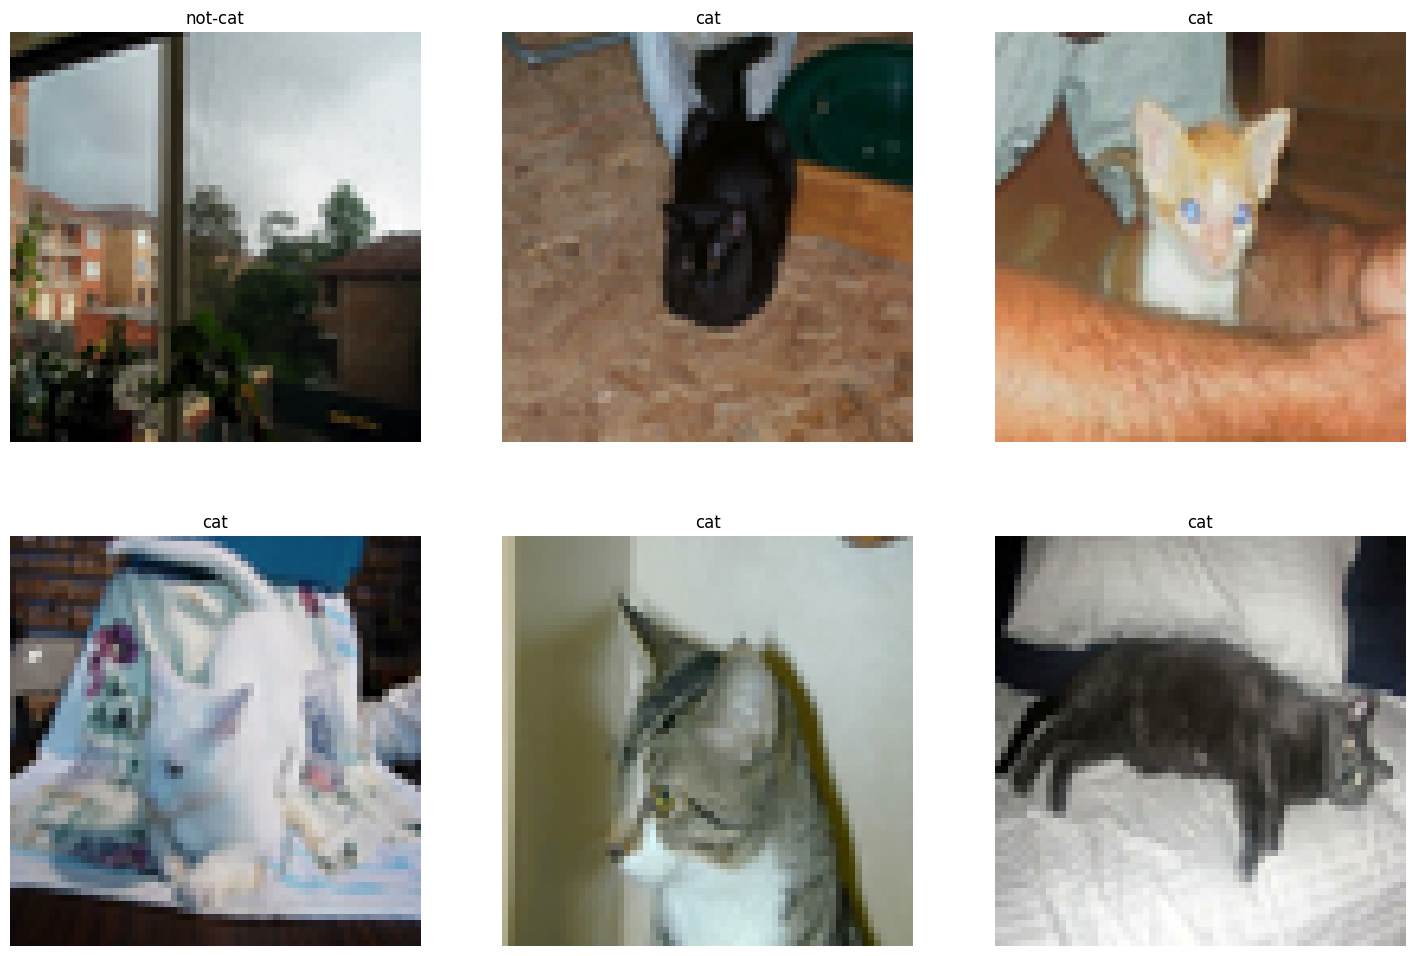

In [7]:
classNames = {value: key for key, value in label_dict.items()}
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()
number_of_examples = len(all_data_processed)
for axis in axes:
    idx = random.randint(0, number_of_examples - 1)
    example = all_data_processed[idx]
    axis.axis('off')
    axis.set_title(f"{classNames[example['Y']]}")
    axis.imshow(example['X'])


##### Proszę o losowe przemieszanie listy danych
Po wczytaniu danych warto je losowo przemieszać — często zbiory są uporządkowane wg klas (np. najpierw same koty, potem same nie-koty), co psułoby podział na zbiór treningowy/testowy.

In [8]:
type(all_data_processed)

list

In [9]:
random.seed(42)
...


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

`random.shuffle(...)` przemiesza listę **w miejscu** (in-place) — nie trzeba przypisywać wyniku.
Wcześniejszy `random.seed(42)` gwarantuje powtarzalność tasowania (każdorazowo ten sam wynik).

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [10]:
# rozwiązanie
random.seed(42)
random.shuffle(all_data_processed)


##### Sprawdźmy wymiary naszych X'ów i Y'ków

In [11]:
X = np.array([example['X'] for example in all_data_processed])
Y = np.array([example['Y'] for example in all_data_processed])
print(f"{bcolors.BOLD}Rozmiar cech (X): {X.shape}, rozmiar flagi/indykatora klasy (Y): {Y.shape}{bcolors.ENDC}")

Rozmiar cech (X): (10000, 64, 64, 3), rozmiar flagi/indykatora klasy (Y): (10000,)


##### Proszę kontynuować kod i stworzyć podzbiory
Po tych wszystkich analizach możemy w końcu podzielić nasze dane na zbiór treningowy i testowy.
##### *Jeśli sieć neuronowa nie będzie się uczyć, wskazując na brak pamięci, proszę znacząco zmniejszyć split_ratio, np. do 0.2*

In [12]:
split_ratio = 0.6
split_idx = int(len(Y) * split_ratio)
ohe = OneHotEncoder()
Y = ohe.fit_transform(Y.reshape(-1, 1))

# Proszę zadeklarować poniższe zmienne korzystając z macierzy X i Y (podpowiedź: slice)
X_train = None
X_test = None
Y_train = None
Y_test = None


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

`X` ma kształt `(N, 64, 64, 3)` — slice po pierwszej osi:
- `X_train = X[:split_idx]` (pierwsze `split_idx` próbek)
- `X_test  = X[split_idx:]` (pozostałe)

Analogicznie dla `Y`. Pamiętaj że `Y` po `OneHotEncoder` jest macierzą rzadką (`scipy.sparse`) — slice działa, ale wymiar to `(N, 2)`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [13]:
# rozwiązanie
X_train = X[:split_idx]
X_test = X[split_idx:]
Y_train = Y[:split_idx]
Y_test = Y[split_idx:]


##### Przypominam tylko, że jest gotowa funkcja do podziału na zbiór treningowy i testowy - w przyszłości polecam stosować (na razie proszę podzielić tę próbkę ręcznie)<br>
from sklearn.model_selection import train_test_split

In [14]:
from sklearn.model_selection import train_test_split

Teraz "rozplączemy" macierze zdjęć 64x64x3 na długie wektory tworząc *X_train_flat* oraz *X_test_flat* <br><br>
**Następuje tutaj jeszcze jedna ważna zmiana w stosunku do regresji logistycznej — wcześniej wymiar zmiennej objaśnianej (Y) wynosił 1 dla jednego pomiaru. Ustaliliśmy, że jeśli predykcja będzie powyżej 0.5 to zaklasyfikujemy obrazek jako kot, jeśli poniżej to jako nie-kot. W sieci neuronowej wyjściem będzie warstwa softmax zwracająca wektor prawdopodobieństw dla wszystkich klas, dlatego zakodujemy nasze Y'ki jako wektor 2-wymiarowy (dla każdego pomiaru), który zawsze będzie miał jedną wartość 0 i jedną wartość 1. Są to tak zwane wektory One-Hot.**

| Klasa | Było (regresja logistyczna) | Będzie (sieć neuronowa) |
| --- | --- | --- |
| Kot | [1] | [0, 1] |
| Nie kot | [0] | [1, 0]|

In [15]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.
Y_train = Y_train.todense()
Y_test = Y_test.todense()

print ("X_train_flat shape: " + str(X_train_flat.shape))
print ("X_test_flat shape: " + str(X_test_flat.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("Y_test shape: " + str(Y_test.shape))

X_train_flat shape: (6000, 12288)
X_test_flat shape: (4000, 12288)
Y_train shape: (6000, 2)
Y_test shape: (4000, 2)


Zostawimy również zdjęcia w postaci macierzy trzywymiarowej (3D) aby wykorzystać w modelu sieci neuronowej przystosowanej do otrzymywania pełnych, a nie zrzutowanych do jednego wektora, obrazków

In [16]:
print ("X_train shape: " + str(X_train.shape))
print ("X_test shape: " + str(X_test.shape))

X_train shape: (6000, 64, 64, 3)
X_test shape: (4000, 64, 64, 3)


## Feed Forward Neural Network

Poniżej stworzymy architekturę pierwszej sieci neuronowej — jest to sieć pełnych połączeń (Feed Forward Neural Network). Wykorzystamy do tego bibliotekę Keras i funkcjonalność *Sequential()* aby zbudować kolejne warstwy sieci.<br><br>
Sieć jest w pewnym sensie kilkoma ułożonymi w warstwy regresjami logistycznymi (tylko często używamy innej funkcji aktywacji niż sigmoida) — czyli np. wyjścia pierwszej regresji logistycznej (pierwszej warstwy) są wejściami dla drugiej regresji logistycznej (drugiej warstwy).<br><br>
Deep Learningiem (uczeniem głębokim) nazywamy struktury w których występuje właśnie taka hierarchia, łańcuch warstw. Główną ideą za tym stojącą jest przypuszczenie, że taki model wyuczy się pewnych meta-cech w warstwach pośrednich/ukrytych. Na przykład, być może sieć uczona na danych dotyczących mieszkań (regresja liniowa) stworzyłaby metacechę oznaczającą jak przestrzenne jest mieszkanie — być może jakaś kombinacja cech wejściowych "wytworzy" taką meta-cechę. Musimy jednak pamiętać, że raczej nie jesteśmy w stanie "odczytać" tych metacech ani ręcznie ich ustawić.<br><br>
**Proszę uzupełnić poniższe linijki (wartości `None` i `"please_fill"`).** Można korzystać z dokumentacji. Również poniżej (po podpowiedzi i rozwiązaniu) sprawdzamy architekturę sieci.

In [17]:
reset_default_graph()
np.random.seed(42)
tf.random.set_seed(42)
try:
    model = Sequential(name='Simple_model')

    # Pierwsza warstwa: 1024 neuronów, wejście = długość rozwiniętego wektora ze zdjęcia (IMG_SIZE*IMG_SIZE*3),
    # inicjalizacja wag = "uniform", aktywacja = "relu"
    model.add(Dense(None, input_dim=None, activation="please_fill", kernel_initializer="please_fill"))

    # Druga warstwa: 128 neuronów, aktywacja "relu", inicjalizacja wag "uniform"
    model.add(Dense(None, activation="please_fill", kernel_initializer="please_fill"))

    # Warstwa wyjściowa: liczba neuronów = liczba klas (2)
    model.add(Dense(None))

    # Aktywacja wyjścia: softmax
    model.add(Activation("please_fill"))

except (TypeError, ValueError):
    print(f'{bcolors.BOLD}{bcolors.FAIL}Proszę poprawnie uzupełnić powyższe miejsca gdzie występuje None lub "please_fill"{bcolors.ENDC}')


Proszę poprawnie uzupełnić powyższe miejsca gdzie występuje None lub "please_fill"


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Każda warstwa `Dense` przyjmuje pozycyjnie liczbę neuronów. Pierwsza warstwa wymaga wymiaru wejścia — dla rozwiniętego obrazka 64×64×3 to `IMG_SIZE * IMG_SIZE * 3`.

Dla klasyfikacji wieloklasowej z one-hot warstwa wyjściowa ma tyle neuronów ile klas (tu: 2), a aktywacja `softmax` zamienia wyjścia na prawdopodobieństwa sumujące się do 1.

`kernel_initializer` to sposób losowania wag startowych — `"uniform"` to rozkład jednostajny.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [18]:
# rozwiązanie
reset_default_graph()
np.random.seed(42)
tf.random.set_seed(42)
model = Sequential(name='Simple_model')
model.add(Dense(1024, input_dim=IMG_SIZE * IMG_SIZE * 3, activation="relu", kernel_initializer="uniform"))
model.add(Dense(128, activation="relu", kernel_initializer="uniform"))
model.add(Dense(2))
model.add(Activation("softmax"))


/Users/kamiljedryczek/Documents/ALK/MachineLearningCodes/MachineLearningCourse/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### Sprawdźmy jak wygląda nasza sieć

In [19]:
model.summary()

Model: "Simple_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1024)           │    12,583,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,715,394 (48.51 MB)

 Trainable params: 12,715,394 (48.51 MB)

 Non-trainable params: 0 (0.00 B)

###### <span style="color: #4a7090;">📊 Spodziewany wynik</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<div>
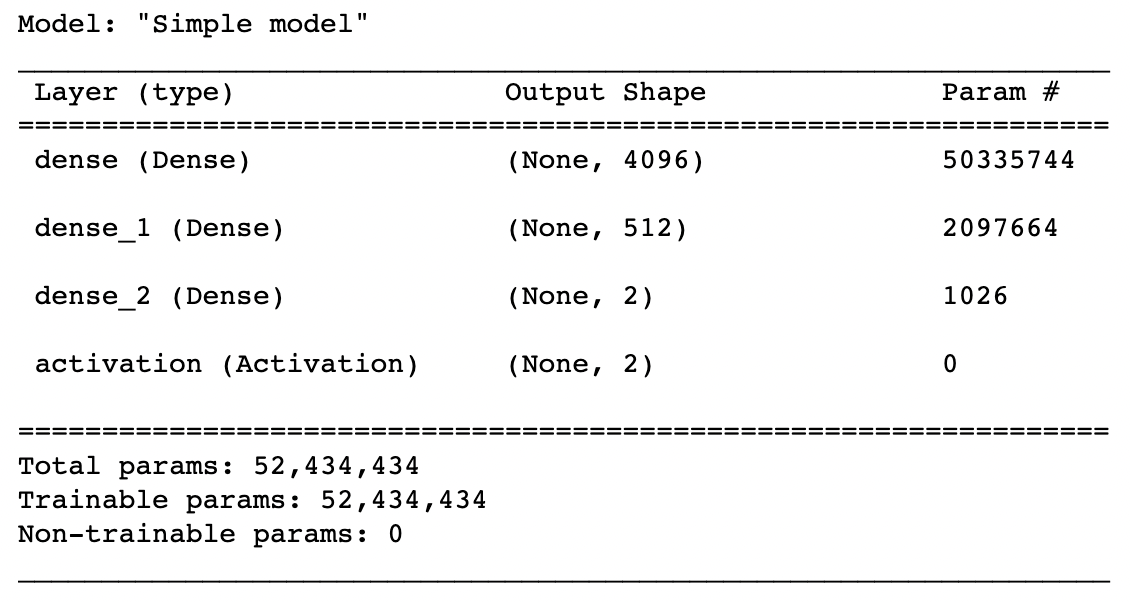
</div>

###### 

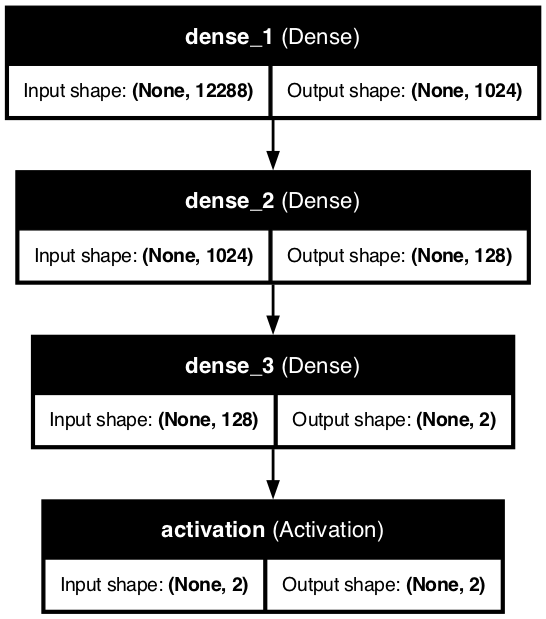

In [20]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png', dpi=100)

###### <span style="color: #4a7090;">📊 Spodziewany wynik</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<div>
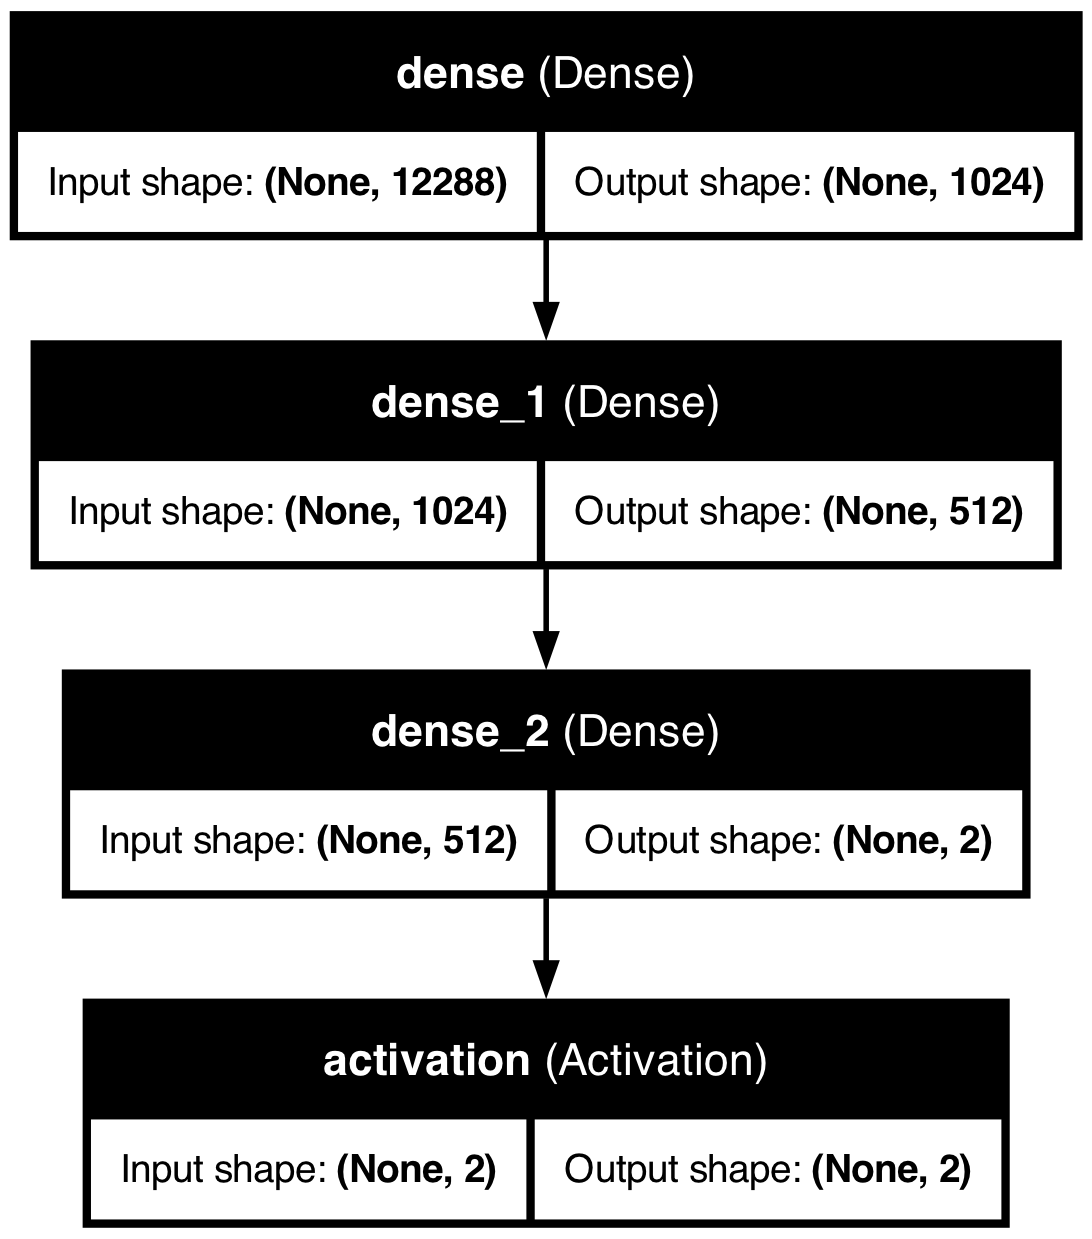
</div>

> **Liczba parametrów: 12 715 394 (~12.7 M).**  
> To bardzo dużo wag — sieć ma sporą pojemność i potrafi „nauczyć się na pamięć" zbioru treningowego.  
> Spodziewany efekt: silny **overfit** — train accuracy szybko rośnie, val accuracy wyraźnie zostaje w tyle (gap ≈ 0.15–0.20).


##### Trenowanie modelu

Powyżej zadeklarowaliśmy architekturę naszej sieci (warstwy, neurony, funkcje aktywacji itd.), jednak aby model mógł się uczyć musimy podać jeszcze szczegóły dotyczące iteracyjnego poruszania w stronę gradientu. W poniższej komórce proszę uzupełnić te informacje zgodnie z podaną instrukcją.

In [21]:
log_dir = os.path.join('logs', 'model', datetime.now().strftime('%Y%m%d-%H%M%S'))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

try:
    # Funkcja kosztu = "binary_crossentropy", optymalizator = Adam(), metryka = "accuracy"
    model.compile(loss="please_fill", optimizer=None, metrics=["please_fill"])

    # Trening: wpierw treningowe X (jeden wektor), potem treningowe Y, liczba epok = 30,
    # batch_size = 32, dane walidacyjne podaj jako tuple (X_test_flat, Y_test)
    history_model = model.fit(
        None, None,
        epochs=None,
        batch_size=None,
        validation_data=None,
        verbose=1,
        callbacks=[tensorboard_callback],
    )
except Exception:
    print(f'{bcolors.BOLD}{bcolors.FAIL}Proszę poprawnie uzupełnić powyższe miejsca gdzie występuje None lub "please_fill"{bcolors.ENDC}')


Proszę poprawnie uzupełnić powyższe miejsca gdzie występuje None lub "please_fill"


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

`model.compile(loss=..., optimizer=..., metrics=[...])` ustawia funkcję kosztu, algorytm optymalizacji i miary śledzone podczas uczenia.

`model.fit(X, Y, epochs=, batch_size=, validation_data=(X_val, Y_val), callbacks=[...])` uczy model. Zwraca obiekt z historią — przyda się później do wykresów (`history_model.history['accuracy']`, `'val_accuracy'`, `'loss'`, `'val_loss'`).

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [22]:
# rozwiązanie
log_dir = os.path.join('logs', 'model', datetime.now().strftime('%Y%m%d-%H%M%S'))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model.compile(loss="binary_crossentropy", optimizer=Adam(), metrics=["accuracy"])
history_model = model.fit(
    X_train_flat, Y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_flat, Y_test),
    verbose=1,
    callbacks=[tensorboard_callback],
)


print(f"Najlepsza val_accuracy: {max(history_model.history['val_accuracy']):.3f}")

ImportError: `keras.optimizers.legacy` is not supported in Keras 3. When using `tf.keras`, to continue using a `tf.keras.optimizers.legacy` optimizer, you can install the `tf_keras` package (Keras 2) and set the environment variable `TF_USE_LEGACY_KERAS=True` to configure TensorFlow to use `tf_keras` when accessing `tf.keras`.

##### **Pod koniec uczenia dokładność (accuracy) dla zbioru treningowego powinna być powyżej 80% zaś dla zbioru testowego (val) około 65%.**

Poniżej wyrysujemy wykres dokładności (accuracy) zbioru treningowego i testowego w zależności od epok/czasu uczenia. Proszę zauważyć, że od pewnego momentu to raczej dokładność na zbiorze treningowym rośnie, a na testowym stoi w miejscu - być może następuje overfitting.

**Dla chętnych**

Ponieważ zapisaliśmy logi do odpowiedniego foldera możemy też zobaczyć jak wygląda tensorboard przez wywołanie komendy w terminalu (oczywiście będąc w odpowiednim folderze):
<br>
<blockquote> tensorboard --logdir=logs/model </blockquote>
<br>
Powyższa komenda poda nam lokalny host, który po skopiowaniu otwieramy w oknie przeglądarki internetowej

In [ ]:
model.save("model_first.keras")

import pickle
with open("history_model.pkl", "wb") as f:
    pickle.dump(history_model.history, f)


In [ ]:
plt.plot(history_model.history['accuracy'])
plt.plot(history_model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.ylim(ymin=0, ymax=1)
plt.show()

Poniżej wykres funkcji kosztu zbioru treningowego i testowego - proszę pamiętać, że uczenie modelu odbywa się poprzez iteracyjne zmniejszanie funkcji kosztu zbioru treningowego, ale model nawet nie powinien znać tej wartości dla zbioru testowego. Proszę zwrócić uwagę jak na początku funkcja kosztu zbioru testowego maleje, ale po chwili zaczyna rosnąć - jest to oczywiście niepożądany skutek i najprawdopodobniej miejsce, od którego zaczynamy "overfittować" model.

In [ ]:
plt.plot(history_model.history['loss'])
plt.plot(history_model.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Dropout
Dropout jest techniką regularyzacji, która podczas uczenia losowo "ucina/zakrywa" połączenia w sieci neuronowej przez co sygnał nie będzie propagowany. Intuicja za tym stojąca jest następująca — to tak, jakby model za każdym razem nie miał dostępu do wszystkich cech: czy wprawny analityk banku będzie w stanie oszacować, czy kredyt powinien być przyznany, gdyby zabrakło mu jednej danej z formularza?


<div>
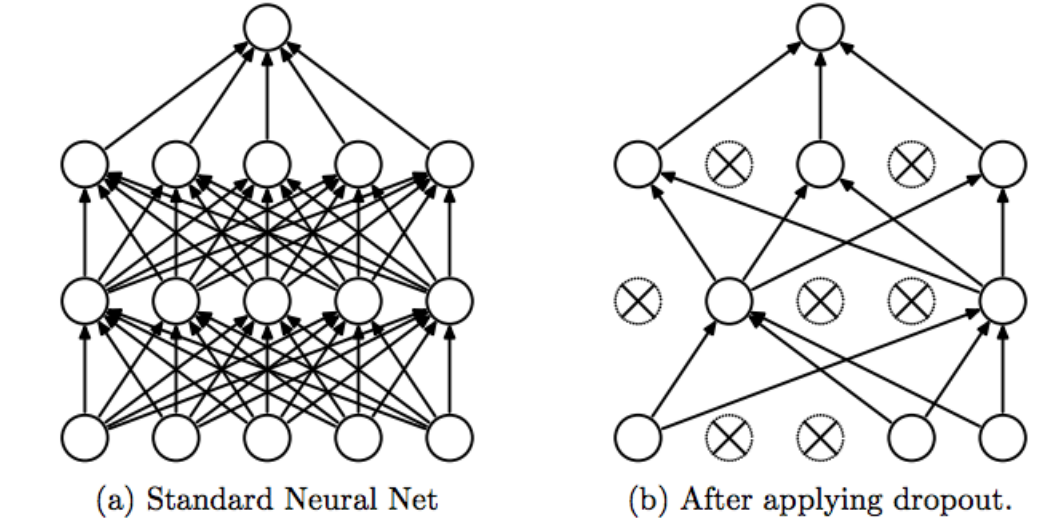
</div>

In [ ]:
reset_default_graph()
np.random.seed(42)
tf.random.set_seed(42)
try:
    
    model_reg = Sequential(name='Model_with_Dropout')

    # Pierwsza warstwa: 1024 neuronów (tak samo jak FFNN)
    model_reg.add(Dense(1024, input_dim=IMG_SIZE*IMG_SIZE*3, activation="relu", kernel_initializer="uniform"))
    
    #proszę podać prawdopodobieństwo ucięcia połączenia - 0.3 czyli 30%
    model_reg.add(Dropout(rate=None))
    
    # Druga warstwa: 128 neuronów
    model_reg.add(Dense(128, activation="relu", kernel_initializer="uniform"))
    
    #proszę podać prawdopodobieństwo ucięcia połączenia - 0.2 czyli 20%
    model_reg.add(Dropout(rate=None))

    model_reg.add(Dense(2))
    model_reg.add(Activation("softmax"))
except Exception:
    print(f'{bcolors.BOLD}{bcolors.FAIL}Proszę poprawnie uzupełnić powyższe miejsca gdzie występuje None lub "please_fill"{bcolors.ENDC}')

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

`Dropout(rate=p)` losowo "wyłącza" frakcję `p` połączeń podczas uczenia (np. `rate=0.5` to 50%).
Wartość `rate` to liczba między 0.0 a 1.0 (włącznie z 0.0, wyłącznie z 1.0).

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
#rozwiązanie
reset_default_graph()
np.random.seed(42)
tf.random.set_seed(42)
model_reg = Sequential(name='Model_with_Dropout')
model_reg.add(Dense(1024, input_dim=IMG_SIZE * IMG_SIZE * 3, activation="relu", kernel_initializer="uniform"))
model_reg.add(Dropout(rate=0.3))
model_reg.add(Dense(128, activation="relu", kernel_initializer="uniform"))
model_reg.add(Dropout(rate=0.2))
model_reg.add(Dense(2))
model_reg.add(Activation("softmax"))

##### Sprawdźmy jak wygląda nasza sieć

In [ ]:
model_reg.summary()

###### <span style="color: #4a7090;">📊 Spodziewany wynik</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<div>
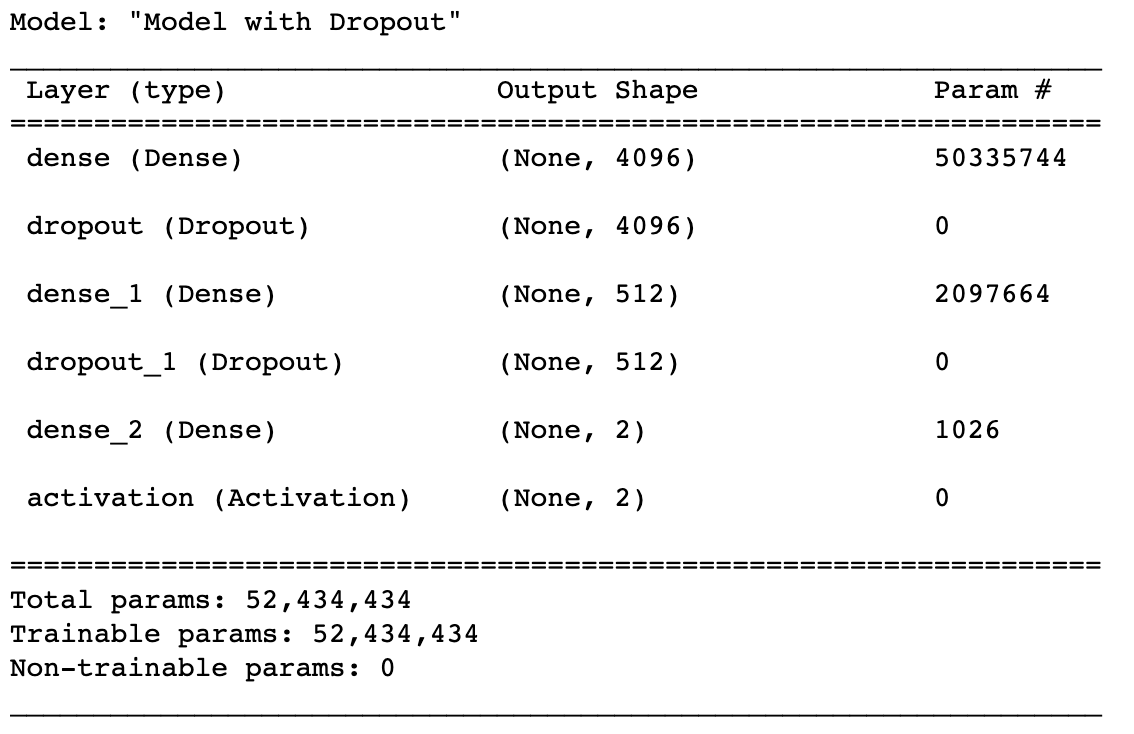
</div>

###### 

In [ ]:
plot_model(model_reg, show_shapes=True, show_layer_names=True, to_file='model_reg.png', dpi=100)

###### <span style="color: #4a7090;">📊 Spodziewany wynik</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<div>
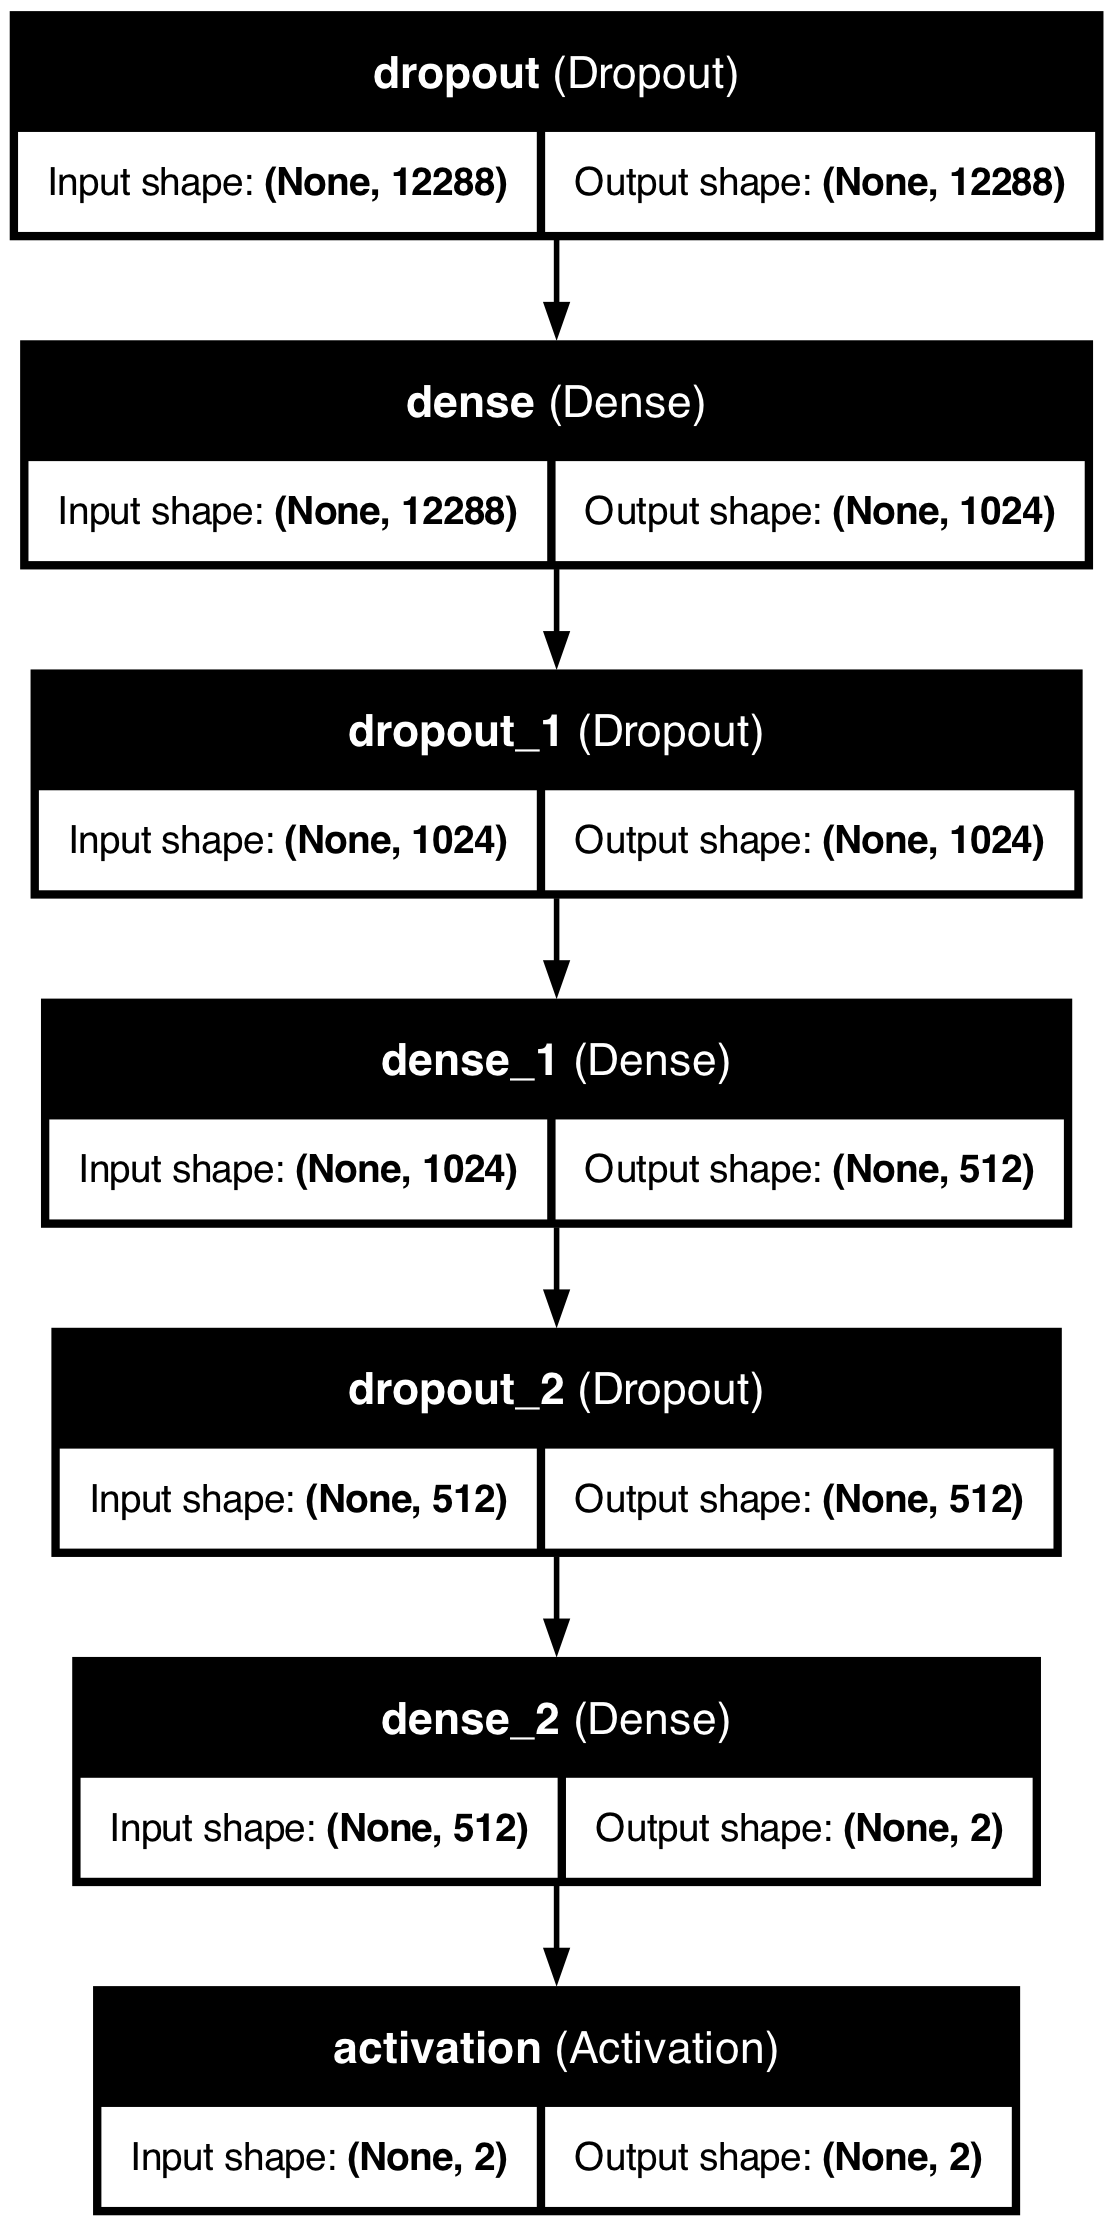
</div>

> **Liczba parametrów: 12 715 394 (~12.7 M) — identyczna jak FFNN.**  
> Warstwy `Dropout` **nie mają wag** (same w sobie nie dodają parametrów), a same warstwy `Dense` są dokładnie takie same jak w modelu bazowym.  
> Mimo identycznej pojemności **overfit dramatycznie spada** (gap z ≈ 0.20 do ≈ 0.07), a val accuracy jest porównywalny lub nieznacznie lepszy.  
> Lekcja: **dropout to czysta regularyzacja — nie zwiększa pojemności, ale uczy sieć generalizować zamiast zapamiętywać.**


##### Trenowanie modelu z regularyzacją

In [ ]:
log_dir = os.path.join('logs', 'regularized_model', datetime.now().strftime('%d_%m_%Y-%H_%M_%S'))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# Apples-to-apples z FFNN: ten sam optimizer (Adam) i batch_size, jedyną różnicą są warstwy Dropout
model_reg.compile(loss="binary_crossentropy", optimizer=Adam(), metrics=["accuracy"])
history_model_reg = model_reg.fit(
    X_train_flat, Y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_flat, Y_test),
    verbose=2,
    callbacks=[tensorboard_callback],
)

model_reg.save("model_reg.keras")
import pickle
with open("history_model_reg.pkl", "wb") as f:
    pickle.dump(history_model_reg.history, f)


print(f"Najlepsza val_accuracy: {max(history_model_reg.history['val_accuracy']):.3f}")

**Pod koniec uczenia dokładność (accuracy) dla zbioru treningowego powinna być blisko 80% zaś dla zbioru testowego (val) powyżej 70%.**
<br><br>
Poniżej wyrysujemy wykres dokładności (accuracy) zbioru treningowego i testowego w zależności od epok/czasu uczenia. Proszę zauważyć, że rośnie dokładność na obu zbiorach i różnica w dokładności pomiędzy nimi w czasie nie jest aż tak duża jak w przypadku modelu bez dropout - to właśnie chcieliśmy osiągnąć.
<br><br>
**Dla chętnych**<br>
Ponieważ zapisaliśmy logi do odpowiedniego foldera możemy też zobaczyć jak wygląda tensorboard przez wywołanie komendy w terminalu (oczywiście będąc w odpowiednim folderze):
<br>
<blockquote> tensorboard --logdir=logs/regularized_model </blockquote>
<br>
Powyższa komenda poda nam lokalny host, który po skopiowaniu otwieramy w oknie przeglądarki internetowej

In [ ]:
fig, axes = plt.subplots(nrows=1 ,ncols=2, figsize=(20,7))

axes[0].plot(history_model_reg.history['accuracy'])
axes[0].plot(history_model_reg.history['val_accuracy'])
axes[0].set_title('regularized model accuracy')
axes[0].set_ylabel('accuracy')
axes[0].set_xlabel('epoch')
axes[0].legend(['train', 'test'], loc='upper left')
axes[0].set_ylim(ymin=0, ymax=1)

axes[1].plot(history_model.history['accuracy'])
axes[1].plot(history_model.history['val_accuracy'])
axes[1].set_title('simple model accuracy')
axes[1].set_ylabel('accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend(['train', 'test'], loc='upper left')
axes[1].set_ylim(ymin=0, ymax=1)
plt.show()

Poniżej porównanie funkcji kosztu dla prostego modelu NN i z regularyzają *dropout*

In [ ]:
fig, axes = plt.subplots(nrows=1 ,ncols=2, figsize=(20,7))

y_max = max(max(history_model_reg.history['loss']), max(history_model_reg.history['val_loss']), max(history_model.history['loss']), max(history_model.history['val_loss']))

axes[0].plot(history_model_reg.history['loss'])
axes[0].plot(history_model_reg.history['val_loss'])
axes[0].set_title('regularized model loss')
axes[0].set_ylabel('loss')
axes[0].set_xlabel('epoch')
axes[0].legend(['train', 'test'], loc='upper left')
axes[0].set_ylim(ymin=0, ymax=y_max)

axes[1].plot(history_model.history['loss'])
axes[1].plot(history_model.history['val_loss'])
axes[1].set_title('simple model loss')
axes[1].set_ylabel('loss')
axes[1].set_xlabel('epoch')
axes[1].legend(['train', 'test'], loc='upper left')
axes[1].set_ylim(ymin=0, ymax=y_max)

plt.show()

In [ ]:
import pickle
model_reg.save("model_reg.keras")
with open("history_model_reg.pkl", "wb") as f:
    pickle.dump(history_model_reg.history, f)

## Konwolucyjna sieć neuronowa (CNN)

Ta architektura sieci jest jedną z najczęściej doradzanych w przypadku pracy nad obrazkami, gdyż może ona wziąć pod uwagę pewne "lokalności" znajdujące się na obrazku. Główną ideą w konwolucyjnych sieciach są tzw. filtry, które przesuwają się po obrazku jak okno przesuwne (sliding window) i operują na lokalnych fragmentach. Podczas uczenia te filtry mogą wyłapać pewne małe kształty, które później sieć może złożyć w bardziej zaawansowane struktury.<br>
Ponieważ chcemy pracować na pełnych obrazkach (macierz 3D) to weźmiemy znormalizowane dane (64x64) X_train i X_test zamiast X_train_flat i X_test_flat. 

In [ ]:
print ("X_train shape: " + str(X_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("Y_test shape: " + str(Y_test.shape))

In [ ]:
X_train_cnn = X_train / 255.
X_test_cnn = X_test / 255.

In [ ]:
reset_default_graph()
np.random.seed(42)
tf.random.set_seed(42)
try:
    model_cnn = Sequential(name="CNN_model")

    # Liczba filtrów = 32, rozmiar filtra (3, 3), aktywacja "relu", inicjalizacja "he_uniform",
    # padding "same", input_shape = pełne wymiary obrazka (IMG_SIZE, IMG_SIZE, 3)
    model_cnn.add(Conv2D(None, (None, None), activation='please_fill', kernel_initializer='please_fill', padding='please_fill', input_shape=(None, None, None)))
    # MaxPooling z rozmiarem filtra (2, 2)
    model_cnn.add(MaxPooling2D((None, None)))

    # Liczba filtrów = 64, reszta jak wyżej
    model_cnn.add(Conv2D(None, (None, None), activation='please_fill', kernel_initializer='please_fill', padding='please_fill'))
    model_cnn.add(MaxPooling2D((2, 2)))

    # Liczba filtrów = 64, reszta jak wyżej
    model_cnn.add(Conv2D(None, (None, None), activation='please_fill', kernel_initializer='please_fill', padding='please_fill'))
    model_cnn.add(MaxPooling2D((None, None)))

    # Rzutujemy wszystko na jeden długi wektor i postępujemy jak ze zwykłą siecią pełnych połączeń
    model_cnn.add(Flatten())
    model_cnn.add(Dropout(rate=0.3))
    model_cnn.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
    model_cnn.add(Dropout(rate=0.3))
    model_cnn.add(Dense(2))
    model_cnn.add(Activation('softmax'))
except Exception:
    print(f'{bcolors.BOLD}{bcolors.FAIL}Proszę poprawnie uzupełnić powyższe miejsca gdzie występuje None lub "please_fill"{bcolors.ENDC}')


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

**Conv2D** — pierwszy argument to liczba filtrów, drugi to rozmiar pojedynczego filtra (`kernel_size`), np. `(3, 3)`. `padding='same'` zachowuje wymiary przestrzenne (wyjście tego samego rozmiaru co wejście).

**MaxPooling2D** — przyjmuje rozmiar okna, np. `(2, 2)` co dwukrotnie zmniejsza wymiar przestrzenny w obu osiach.

`input_shape=(IMG_SIZE, IMG_SIZE, 3)` — pełny obrazek 3D (wysokość, szerokość, kanały RGB).

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
#rozwiązanie
reset_default_graph()
np.random.seed(42)
tf.random.set_seed(42)
model_cnn = Sequential(name="CNN_model")

model_cnn.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Dropout(0.3))

model_cnn.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Dropout(0.3))


model_cnn.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Dropout(0.3))


model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model_cnn.add(Dropout(rate=0.3))
model_cnn.add(Dense(2))
model_cnn.add(Activation('softmax'))


##### Sprawdźmy jak wygląda nasza sieć

In [ ]:
model_cnn.summary()

In [ ]:
plot_model(model_cnn, show_shapes=True, show_layer_names=True, to_file='model_cnn.png', dpi=100)

###### <span style="color: #4a7090;">📊 Spodziewany wynik</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<div>
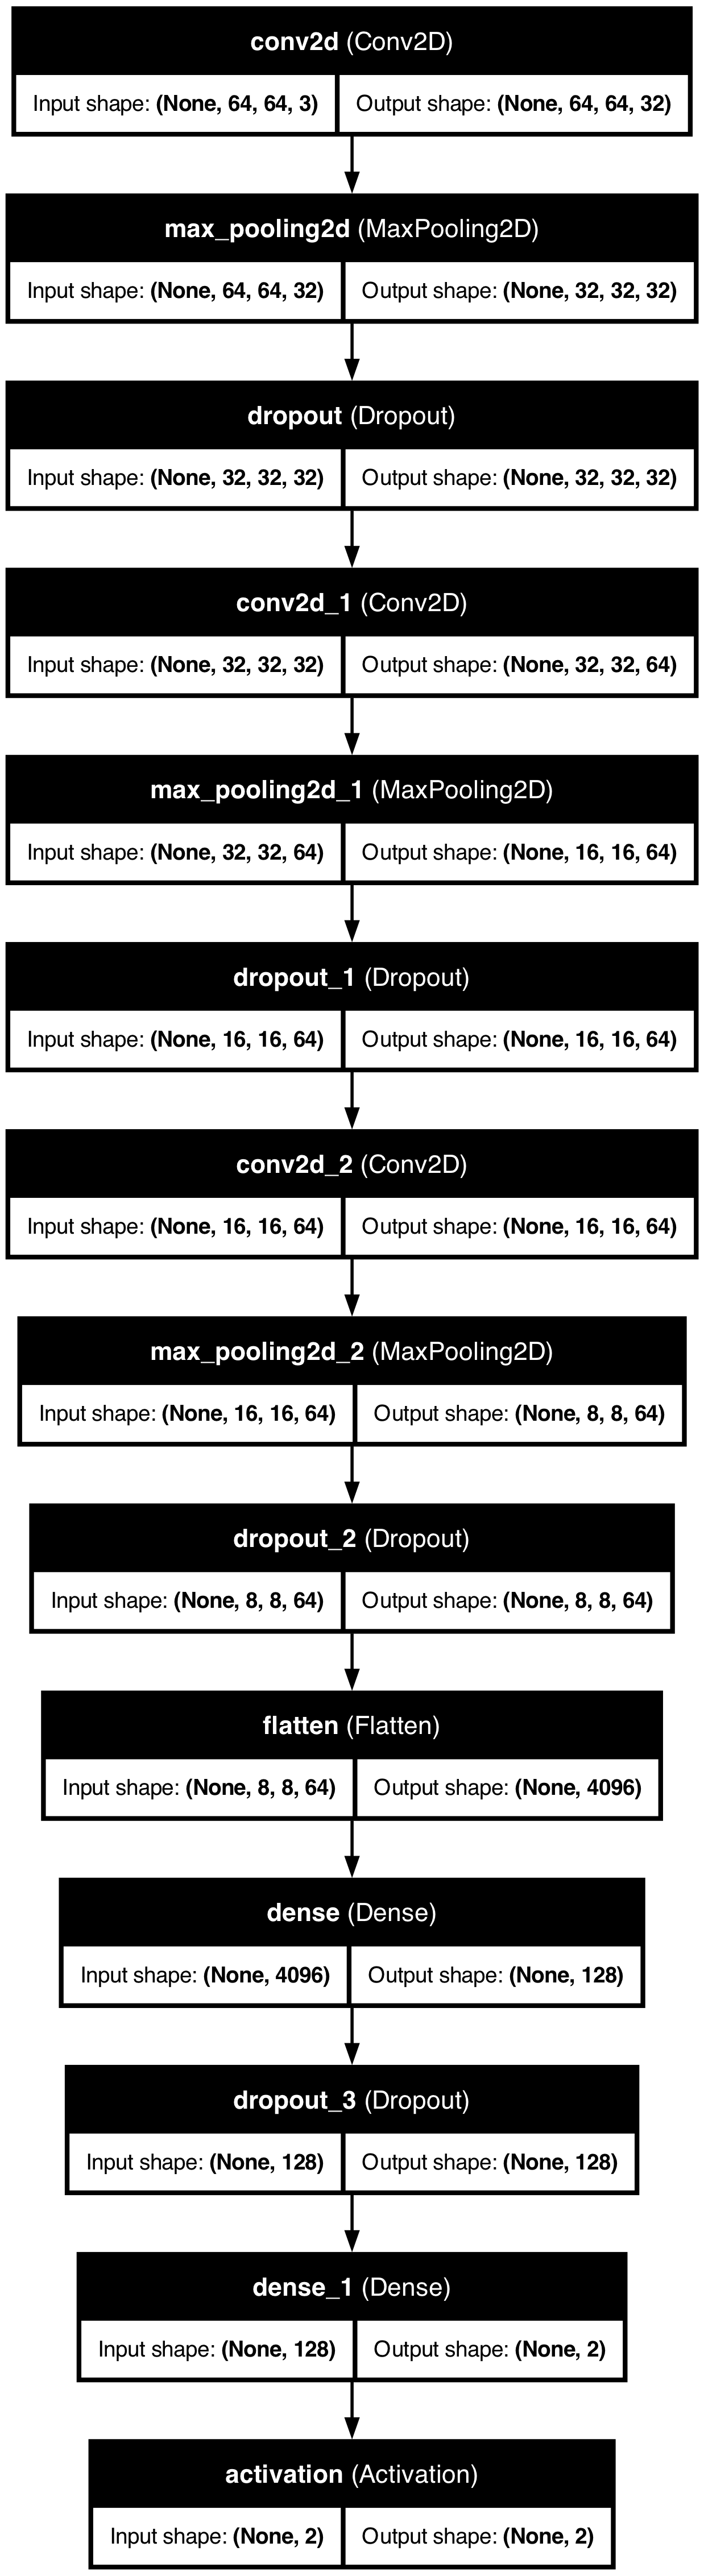
</div>

> **Liczba parametrów: 580 994 (~581 K) — ponad 22× mniej niż FFNN/Dropout.**  
> A jednak CNN osiąga val accuracy ≈ 0.89–0.90, podczas gdy FFNN/Dropout zatrzymują się na ≈ 0.66–0.72.  
> Powód: konwolucje mają **właściwy *inductive bias* dla obrazów** — wykrywają lokalne wzorce (krawędzie, tekstury, kształty) i są niezmiennicze na przesunięcie. Dense networks na spłaszczonych pikselach traktują każdy piksel niezależnie i nie potrafią wykryć struktury przestrzennej.  
> Lekcja: **dobór architektury bije liczbę parametrów** — mała sieć z odpowiednim biasem indukcyjnym pokona wielką sieć z niedopasowaną architekturą.


##### Trenowanie modelu CNN

In [ ]:
log_dir = os.path.join('logs','cnn_model', datetime.now().strftime('%d_%m_%Y-%H_%M_%S'))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
model_cnn.compile(loss="binary_crossentropy", optimizer=Adam(), metrics=["accuracy"])
history_model_cnn = model_cnn.fit(X_train_cnn, Y_train, epochs=30, batch_size=64, verbose=2, validation_data=[X_test_cnn, Y_test], callbacks=[tensorboard_callback])

model_cnn.save("model_cnn.keras")
import pickle
with open("history_model_cnn.pkl", "wb") as f:
    pickle.dump(history_model_cnn.history, f)


print(f"Najlepsza val_accuracy: {max(history_model_cnn.history['val_accuracy']):.3f}")

In [ ]:
model_cnn.save("model_cnn.keras")
import pickle
with open("history_model_cnn.pkl", "wb") as f:
    pickle.dump(history_model_cnn.history, f)

**Pod koniec uczenia dokładność (accuracy) dla zbioru treningowego powinna być powyżej 90% zaś dla zbioru testowego (val) około 90%.**
<br><br>
Poniżej wyrysujemy wykres dokładności (accuracy) zbioru treningowego i testowego w zależności od epok/czasu uczenia oraz funkcji kosztu.
<br><br>
**Dla chętnych**<br>
Ponieważ zapisaliśmy logi do odpowiedniego foldera możemy też zobaczyć jak wygląda tensorboard przez wywołanie komendy w terminalu (oczywiście będąc w odpowiednim folderze):
<br>
<blockquote> tensorboard --logdir=logs/cnn_model </blockquote>
<br>
Powyższa komenda poda nam lokalny host, który po skopiowaniu otwieramy w oknie przeglądarki internetowej

In [ ]:
plt.plot(history_model_cnn.history['accuracy'])
plt.plot(history_model_cnn.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.ylim(ymin=0, ymax=1)
plt.show()

In [ ]:
plt.plot(history_model_cnn.history['loss'])
plt.plot(history_model_cnn.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Sprawdź swoje zdjęcie

W poniższych komórkach można podać swoje zdjęcie (z dysku lub internetu) aby na żywo dokonać predykcji.
<br><br>
Funkcje `predict_image_from_files` oraz `predict_image_from_urls` przyjmują:
- **jeden model** — np. `model_cnn`
- **listę modeli** — np. `[model, model_reg, model_cnn]` (nazwy brane z `model.name`)
- **dict** — np. `{"Simple": model, "Dropout": model_reg, "CNN": model_cnn}`

In [ ]:
# %run zaladuj_modele.py

In [ ]:
my_button = SelectFilesButton()
my_button  # wyświetla przycisk wyboru plików


In [ ]:
predict_image_from_files([model, model_reg, model_cnn], my_button, classNames)

In [ ]:
# Przykładowe URLe do testowania — odkomentuj które chcesz.
# TP = True Positive, TN = True Negative, FP = False Positive, FN = False Negative

urls = [
    'https://raw.githubusercontent.com/fastai/fastai/main/nbs/images/cat.jpg',                                          # TP — kot
    'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123597_Siamese_cat.JPEG',            # TP — kot syjamski
    'https://upload.wikimedia.org/wikipedia/commons/1/15/Cat_August_2010-4.jpg',                                       # TP — kot pręgowany
    'https://upload.wikimedia.org/wikipedia/commons/7/71/Nursing_Cat_01.jpg',                                          # TP — kotka z kociętami
    'https://upload.wikimedia.org/wikipedia/commons/b/b6/Felis_catus-cat_on_snow.jpg',                                 # TP — kot na śniegu
    'https://upload.wikimedia.org/wikipedia/commons/9/9b/Gustav_chocolate.jpg',                                        # FN — brązowy kot, model się myli
    'https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/test_images/image1.jpg',      # FP — dwa psy beagle, model się myli
    'https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/test_images/image2.jpg',      # TN — kitesurferzy na plaży
    'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01614925_bald_eagle.JPEG',            # TN — bielik
    'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n07734744_mushroom.JPEG',              # TN — grzyb
    'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n03445777_golf_ball.JPEG',             # TN — piłka golfowa
]

predict_image_from_urls([model, model_reg, model_cnn], urls, classNames)